# Lab 03 - 2: Solutions #

In [1]:
import cv2
import matplotlib.pyplot as plt

from yolov3.darknet import Darknet
from yolov3.utils import *

In [2]:
# Set the location and name of the cfg file.
cfg_file = './yolov3/cfg/yolov3.cfg'

# Set the location and name of the pre-trained weights file.
weight_file = './yolov3/weights/yolov3.weights'

# Set the location and name of the COCO object classes file.
namesfile = './yolov3/data/coco.names'

# Load the network architecture.
model = Darknet(cfg_file)

# Load the pre-trained weights.
model.load_weights(weight_file)

# Load the COCO object classes.
class_names = load_class_names(namesfile)

# Print the neural network used in YOLOv3.
model.print_network()


layer     filters    size              input                output
    0 conv     32  3 x 3 / 1   416 x 416 x   3   ->   416 x 416 x  32
    1 conv     64  3 x 3 / 2   416 x 416 x  32   ->   208 x 208 x  64
    2 conv     32  1 x 1 / 1   208 x 208 x  64   ->   208 x 208 x  32
    3 conv     64  3 x 3 / 1   208 x 208 x  32   ->   208 x 208 x  64
    4 shortcut 1
    5 conv    128  3 x 3 / 2   208 x 208 x  64   ->   104 x 104 x 128
    6 conv     64  1 x 1 / 1   104 x 104 x 128   ->   104 x 104 x  64
    7 conv    128  3 x 3 / 1   104 x 104 x  64   ->   104 x 104 x 128
    8 shortcut 5
    9 conv     64  1 x 1 / 1   104 x 104 x 128   ->   104 x 104 x  64
   10 conv    128  3 x 3 / 1   104 x 104 x  64   ->   104 x 104 x 128
   11 shortcut 8
   12 conv    256  3 x 3 / 2   104 x 104 x 128   ->    52 x  52 x 256
   13 conv    128  1 x 1 / 1    52 x  52 x 256   ->    52 x  52 x 128
   14 conv    256  3 x 3 / 1    52 x  52 x 128   ->    52 x  52 x 256
   15 shortcut 12
   16 conv    128  1 x 

### Loading and Resizing Images ###

In the code below, we have to load our images using OpenCV's `cv2.imread()` function. Since this function loads images as BGR we need to convert our images to RGB, in order to display them with the correct colors.

As we can see in the previous cell, the input size of the first layer of the network is 416x416x3. Since images have different sizes, we have to resize our images to be compatible with the input size of the first layer in the network( use the `cv2.resize()` function). Then, we plot the original and resized images.

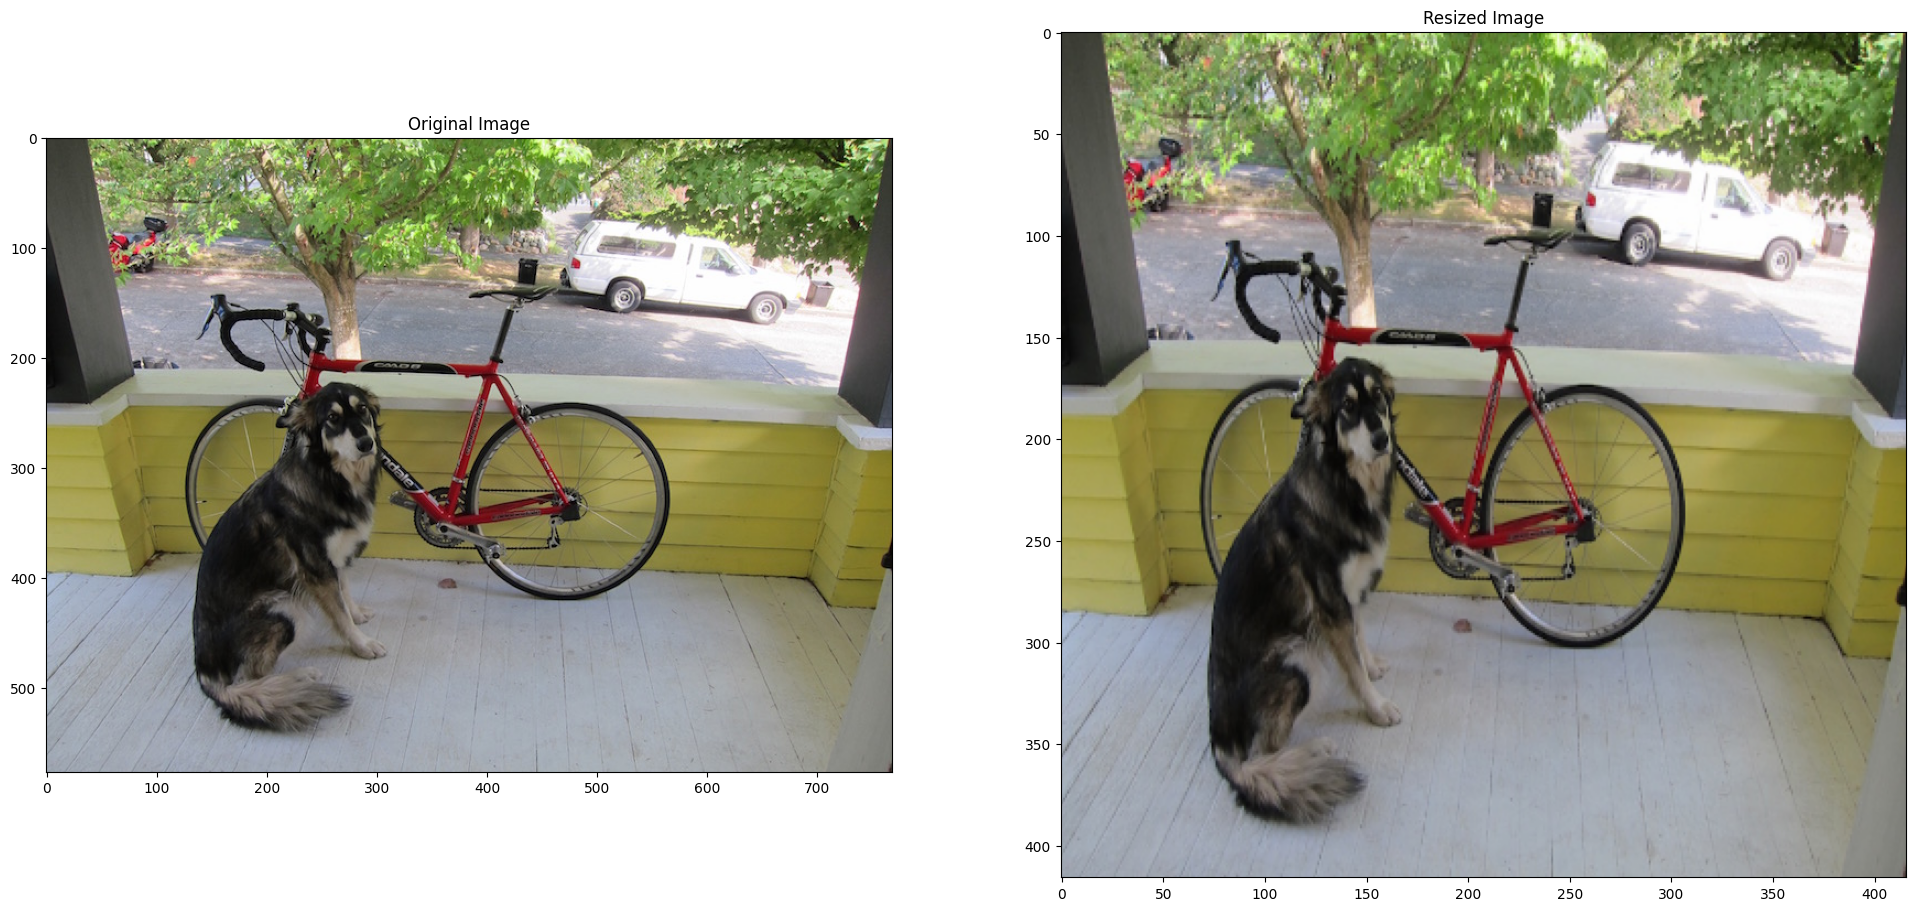

In [3]:
# Set the default figure size.
plt.rcParams['figure.figsize'] = [24.0, 14.0]

# Load the image.
img = cv2.imread('./yolov3/images/dog.jpg')

# Convert the image to RGB.
original_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# We resize the image to the input width and height of the first layer of the network.    
resized_image = cv2.resize(original_image, (model.width, model.height))

# Display the images.
plt.subplot(121)
plt.title('Original Image')
plt.imshow(original_image)
plt.subplot(122)
plt.title('Resized Image')
plt.imshow(resized_image)
plt.show()

### Setting the Non-Maximal Suppression Threshold ###

As seen during the first part of the lesson, YOLO uses Non-Maximal Suppression (NMS) to only keep the best bounding box. The first step in NMS is to remove all the predicted bounding boxes that have a detection probability that is less than a given NMS threshold.

In the code below, set this NMS threshold to 0.6. This means that all predicted bounding boxes that have a detection probability of less than 0.6 will be removed.

In [4]:
# Set the NMS threshold.
nms_thresh = 0.6

### Setting the Intersection Over Union Threshold ###

After removing all the predicted bounding boxes that have a low detection probability, the second step in NMS is to select the bounding boxes with the highest detection probability and eliminate all the bounding boxes whose Intersection Over Union (IOU) value is higher than a given IOU threshold. 

In the code below, set this IOU threshold to 0.4. This means that all predicted bounding boxes that have an IOU value greater than 0.4 with respect to the best bounding boxes will be removed.

In the `utils` module you will find the `nms` function, which performs the second step of Non-Maximal Suppression, and the `boxes_iou` function that calculates the Intersection Over Union of two given bounding boxes. You are encouraged to look at these functions to see how they work.

In [5]:
# Set the IOU threshold.
iou_thresh = 0.4

### Object Detection ###

Once the image has been loaded and resized, and you have chosen your parameters for `nms_thresh` and `iou_thresh`, we have to use the YOLO algorithm to detect objects in the image. We detect the objects using the `detect_objects(m, resized_image, iou_thresh, nms_thresh)` function from the `utils` module. This function takes in the model returned by Darknet, the resized image, the NMS, and IOU thresholds. And, it returns the bounding boxes of the objects found.

Each bounding box contains the following parameters: *i)* the coordinates `(x, y)` of the center of the bounding box, *ii)* the width `w` and height `h` of the bounding box, *iii)* the confidence detection level, *iv)* the object class probability, *v)* and the object class id. The `detect_objects()` function also prints out the time it took for the YOLO algorithm to detect the objects in the image and the number of objects detected.

Once we have the bounding boxes of the objects found by YOLO, we have to print the class of the objects found and their corresponding object class probability. To do this we use the `print_objects()` function in the `utils` module.

Finally, use the `plot_boxes()` function to plot the bounding boxes and corresponding object class labels found by YOLO in our image. If you set the `plot_labels` flag to `False` you will display the bounding boxes with no labels. This makes it easier to view the bounding boxes if your `nms_thresh` is too low. The `plot_boxes()` function uses the same color to plot the bounding boxes of the same object class. However, if you want all bounding boxes to be the same color, you can use the `color` keyword to set the desired color. For example, if you want all the bounding boxes to be red you can use:
    `plot_boxes(original_image, boxes, class_names, plot_labels=True, color=(1,0,0))`

You are encouraged to change the `iou_thresh` and `nms_thresh` parameters to see how they affect the YOLO detection algorithm. The default values of `iou_thresh=0.4` and `nms_thresh=0.6` work well to detect objects in different kinds of images. In the cell below, I have repeated some of the code used before in order to prevent you from scrolling up and down when you want to change the `iou_thresh` and `nms_thresh` parameters or the image.



It took 0.159 seconds to detect the objects in the image.

Number of Objects Detected: 3 

Objects Found and Confidence Level:

1. dog: 0.999997
2. truck: 0.991655
3. bicycle: 0.999998


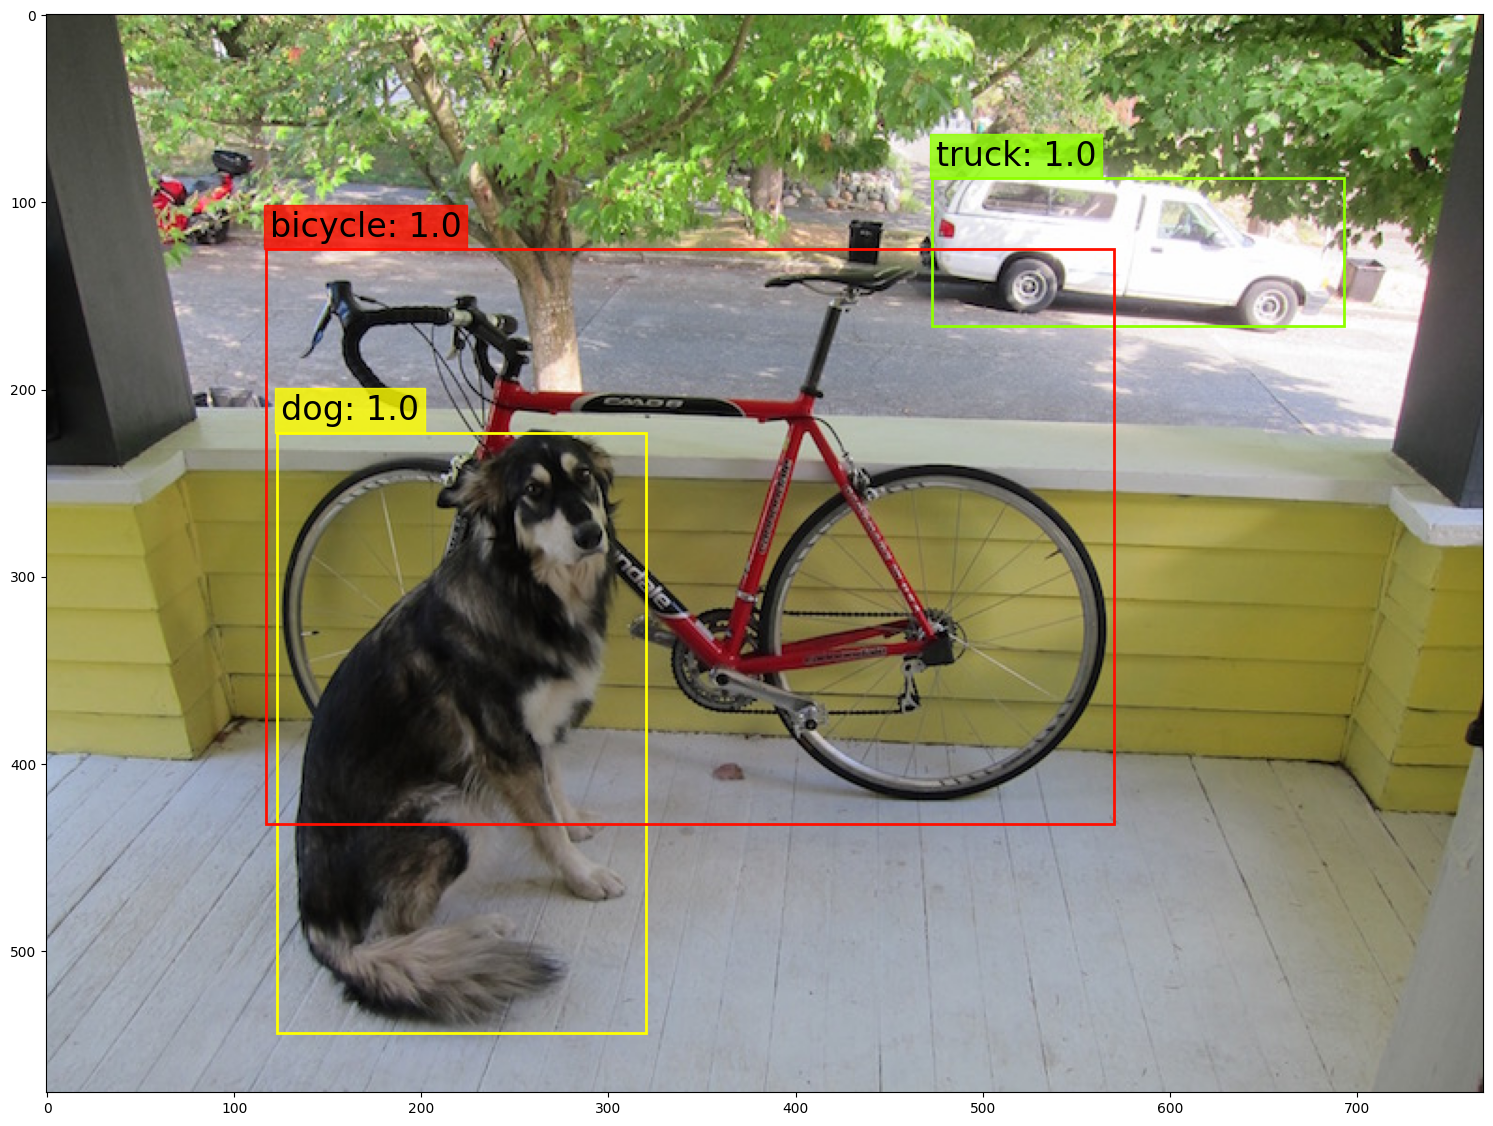

In [6]:
# Set the default figure size.
plt.rcParams['figure.figsize'] = [24.0, 14.0]

# Load the image.
img = cv2.imread('./yolov3/images/dog.jpg')

# Convert the image to RGB.
original_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# We resize the image to the input width and height of the first layer of the network.    
resized_image = cv2.resize(original_image, (model.width, model.height))

# Set the IOU threshold. Default value is 0.4.
iou_thresh = 0.4

# Set the NMS threshold. Default value is 0.6.
nms_thresh = 0.6

# Detect objects in the image.
boxes = detect_objects(model, resized_image, iou_thresh, nms_thresh)

# Print the objects found and the confidence level.
print_objects(boxes, class_names)

#Plot the image with bounding boxes and corresponding object class labels.
plot_boxes(original_image, boxes, class_names, plot_labels=True)